# Generating RBS Calculator Data and Validation
In  this notebook, we demonstrate sampling approaches to generating synthetic consignments from RBS calculator data

In [7]:
from pathlib import Path
import pandas as pd
import numpy as np


In [5]:
datadir = Path("data/fake_pis_data.csv")    
df = pd.read_csv(datadir)
df = df.dropna()
df

,INSPECTION_NUMBER,INSPECTION_LOCATION_NAME,PATHWAY,COUNTRY_OF_ORIGIN_NAME,PROPAGATIVE_MATERIAL_TYPE,TOTAL_SAMPLING_UNITS,TOTAL_PLANT_QUANTITY,PRODUCER
0,INS-6127,Miami PIS,Sea,Japan,"Root cutting, crown, or clump, Tuberous Root",263,18879,Rocket Farms
1,INS-8544,Miami PIS,Air,Netherlands,"Bulb, Corm, Rhizome, Tuberous Stem",46,470,White's Nursery & Greenhouses Inc.
2,INS-6098,Miami PIS,Sea,Netherlands,"Bulb, Corm, Rhizome, Tuberous Stem",25,5,Grower Direct Farms
3,INS-6636,Miami PIS,Sea,New Zeland,Meristem or Callus Tissue Culture (micropropag...,506,24161,DeLeon's Bromeliads
4,INS-3963,Miami PIS,Train,Japan,"Root cutting, crown, or clump, Tuberous Root",148,1859,Ocean Breeze International
...,...,...,...,...,...,...,...,...
493,INS-1079,Atlanta PIS,Air,Japan,"Root cutting, crown, or clump, Tuberous Root",443,16321,Kent's Bromeliads Nursery Inc.
494,INS-7205,Atlanta PIS,Sea,New Zeland,Budwood/Graftwood (scion),332,16067,Delray Plants Inc.
495,INS-2328,Atlanta PIS,Air,Netherlands,"Bulb, Corm, Rhizome, Tuberous Stem",980,33721,Colorama Wholesale Nursery
496,INS-3945,Atlanta PIS,Air,Japan,Meristem or Callus Tissue Culture (micropropag...,392,23391,Henry Mast Greenhouses/Masterpiece Flower Co LLC


In [12]:
# Naive approach (baseline)

def multinomial_sample(df, columns, n_samples=1, random_state=None):
    np.random.seed(random_state)
    sampled = {}
    for col in columns:
        values, counts = np.unique(df[col], return_counts=True)
        probs = counts / counts.sum()
        sampled[col] = np.random.choice(values, size=n_samples, p=probs)
    return pd.DataFrame(sampled)

In [13]:
cols = [
    'INSPECTION_NUMBER',
    'INSPECTION_LOCATION_NAME',
    'PATHWAY',
    'COUNTRY_OF_ORIGIN_NAME',
    'PROPAGATIVE_MATERIAL_TYPE',
    'TOTAL_SAMPLING_UNITS',
    'TOTAL_PLANT_QUANTITY',
    'PRODUCER',
]
sampled_df = multinomial_sample(df, columns=cols, n_samples=5000, random_state=42)
sampled_df

,INSPECTION_NUMBER,INSPECTION_LOCATION_NAME,PATHWAY,COUNTRY_OF_ORIGIN_NAME,PROPAGATIVE_MATERIAL_TYPE,TOTAL_SAMPLING_UNITS,TOTAL_PLANT_QUANTITY,PRODUCER
0,INS-4386,Los Angeles PIS,Air,Japan,Meristem or Callus Tissue Culture (micropropag...,77,27131,Northwest Horticulture
1,INS-9555,Miami PIS,Air,Netherlands,Budwood/Graftwood (scion),52,15475,Altman Plants
2,INS-7546,Miami PIS,Air,Japan,"Bulb, Corm, Rhizome, Tuberous Stem",605,75120,Northwest Horticulture
3,INS-6494,Los Angeles PIS,Sea,India,Meristem or Callus Tissue Culture (micropropag...,963,5605,Battlefield Farms
4,INS-2328,Miami PIS,Air,India,"Bulb, Corm, Rhizome, Tuberous Stem",500,23575,Paul Ecke Ranch
...,...,...,...,...,...,...,...,...
4995,INS-9111,Miami PIS,Sea,New Zeland,"Bulb, Corm, Rhizome, Tuberous Stem",952,14646,Polk Nursery Company Inc.
4996,INS-1976,Miami PIS,Air,India,Meristem or Callus Tissue Culture (micropropag...,754,15592,Rocket Farms
4997,INS-3964,Miami PIS,Air,Japan,"Root cutting, crown, or clump, Tuberous Root",12,19235,Dewar Nurseries
4998,INS-8477,Los Angeles PIS,Sea,Japan,Meristem or Callus Tissue Culture (micropropag...,382,75205,Henry Mast Greenhouses/Masterpiece Flower Co LLC


In [21]:
def sequential_multinomial_sample(df, columns, n_samples=1, random_state=None):
    np.random.seed(random_state)
    samples = []
    for _ in range(n_samples):
        subset = df
        sample = {}
        for col in columns:
            values, counts = np.unique(subset[col], return_counts=True)
            probs = counts / counts.sum()
            chosen = np.random.choice(values, p=probs)
            sample[col] = chosen
            subset = subset[subset[col] == chosen]
            if subset.empty:
                # If no rows left, break and sample from original df for remaining columns
                for rem_col in columns[len(sample):]:
                    values, counts = np.unique(df[rem_col], return_counts=True)
                    probs = counts / counts.sum()
                    sample[rem_col] = np.random.choice(values, p=probs)
                break
        samples.append(sample)
    return pd.DataFrame(samples)


In [20]:
sequential_sampled_df = sequential_multinomial_sample(df, columns=cols, n_samples=5000, random_state=42)
sequential_sampled_df

,INSPECTION_NUMBER,INSPECTION_LOCATION_NAME,PATHWAY,COUNTRY_OF_ORIGIN_NAME,PROPAGATIVE_MATERIAL_TYPE,TOTAL_SAMPLING_UNITS,TOTAL_PLANT_QUANTITY,PRODUCER
0,INS-4386,Miami PIS,Sea,Netherlands,"Root cutting, crown, or clump, Tuberous Root",19,300,Sawyer Nursery
1,INS-6498,Miami PIS,Sea,Netherlands,"Bulb, Corm, Rhizome, Tuberous Stem",544,31596,Kawahara Nurseries
2,INS-3818,Miami PIS,Air,Japan,Meristem or Callus Tissue Culture (micropropag...,789,36930,California Pajarosa
3,INS-4976,Miami PIS,Sea,India,Meristem or Callus Tissue Culture (micropropag...,278,16679,Gallup & Stribling Orchids Inc.
4,INS-1508,Atlanta PIS,Air,Japan,"Bulb, Corm, Rhizome, Tuberous Stem",297,1984,DeLeon's Bromeliads
...,...,...,...,...,...,...,...,...
4995,INS-1712,Miami PIS,Air,New Zeland,Meristem or Callus Tissue Culture (micropropag...,119,153,Hermann Engelmann Greenhouses
4996,INS-2582,Atlanta PIS,Air,Netherlands,"Bulb, Corm, Rhizome, Tuberous Stem",577,31405,Bob's Market & Greenhouses Inc.
4997,INS-3993,Miami PIS,Train,Japan,"Bulb, Corm, Rhizome, Tuberous Stem",717,30272,Timberline Nursery Inc.
4998,INS-1145,Los Angeles PIS,Air,India,Budwood/Graftwood (scion),781,31662,Bob's Market & Greenhouses Inc.


In [41]:
from sklearn.mixture import GaussianMixture

def gmm_sample(df, columns, n_samples=1, random_state=None, n_components=3):
    # Only works for numeric columns
    numeric_cols = [col for col in columns if np.issubdtype(df[col].dtype, np.number)]
    cat_cols = [col for col in columns if col not in numeric_cols]
    
    # Fit GMM on numeric columns
    gmm = GaussianMixture(n_components=n_components, random_state=random_state)
    gmm.fit(df[numeric_cols])
    sampled_numeric, _ = gmm.sample(n_samples)
    sampled_numeric = pd.DataFrame(sampled_numeric, columns=numeric_cols)
    # Round and cast to int for count columns
    for col in numeric_cols:
        sampled_numeric[col] = np.round(sampled_numeric[col]).astype(int)
        # Clip to observed min/max
        sampled_numeric[col] = sampled_numeric[col].clip(df[col].min(), df[col].max())
    
    # For categorical columns, sample independently as in naive
    sampled_cat = {}
    for col in cat_cols:
        values, counts = np.unique(df[col], return_counts=True)
        probs = counts / counts.sum()
        sampled_cat[col] = np.random.choice(values, size=n_samples, p=probs)
    sampled_cat = pd.DataFrame(sampled_cat)
    
    # Combine
    sampled = pd.concat([sampled_cat, sampled_numeric], axis=1)
    # Reorder columns to match input
    sampled = sampled[columns]
    return sampled


In [ ]:
gmm_sampled_df = gmm_sample(df, columns=cols, n_samples=5000, random_state=42, n_components=3)
gmm_sampled_df

,INSPECTION_NUMBER,INSPECTION_LOCATION_NAME,PATHWAY,COUNTRY_OF_ORIGIN_NAME,PROPAGATIVE_MATERIAL_TYPE,TOTAL_SAMPLING_UNITS,TOTAL_PLANT_QUANTITY,PRODUCER
0,INS-1298,Atlanta PIS,Sea,India,"Root cutting, crown, or clump, Tuberous Root",746,18414,Pacifica Flowers
1,INS-8562,Miami PIS,Air,New Zeland,"Root cutting, crown, or clump, Tuberous Root",416,5465,Battlefield Farms
2,INS-3250,Miami PIS,Train,New Zeland,"Bulb, Corm, Rhizome, Tuberous Stem",171,5509,Elzinga & Hoeksema Greenhouses
3,INS-3607,Miami PIS,Sea,Japan,"Bulb, Corm, Rhizome, Tuberous Stem",1,9975,Ocean Breeze International
4,INS-3065,Miami PIS,Sea,Japan,Budwood/Graftwood (scion),1,5,Myriad Flowers International
...,...,...,...,...,...,...,...,...
4995,INS-4741,Los Angeles PIS,Air,New Zeland,"Root cutting, crown, or clump, Tuberous Root",344,13121,Sawyer Nursery
4996,INS-6734,Los Angeles PIS,Sea,India,"Bulb, Corm, Rhizome, Tuberous Stem",771,37643,Rockwell Farms Inc.
4997,INS-9611,Los Angeles PIS,Train,India,Meristem or Callus Tissue Culture (micropropag...,507,26098,Operation
4998,INS-9632,Atlanta PIS,Air,India,Budwood/Graftwood (scion),596,26895,Kerry's Bromeliads


In [44]:
from scipy.stats import wasserstein_distance

# Compute Wasserstein distance for 'TOTAL_SAMPLING_UNITS' grouped by 'INSPECTION_LOCATION_NAME'
locations = df['INSPECTION_LOCATION_NAME'].unique()
wasserstein_results = []

for loc in locations:
    orig = df[df['INSPECTION_LOCATION_NAME'] == loc]['TOTAL_SAMPLING_UNITS']
    naive = sampled_df[sampled_df['INSPECTION_LOCATION_NAME'] == loc]['TOTAL_SAMPLING_UNITS']
    seq = sequential_sampled_df[sequential_sampled_df['INSPECTION_LOCATION_NAME'] == loc]['TOTAL_SAMPLING_UNITS']
    gmm = gmm_sampled_df[sequential_sampled_df['INSPECTION_LOCATION_NAME'] == loc]['TOTAL_SAMPLING_UNITS']
    w_naive = wasserstein_distance(orig, naive)
    w_seq = wasserstein_distance(orig, seq)
    w_gmm = wasserstein_distance(orig, gmm)
    wasserstein_results.append({
        'INSPECTION_LOCATION_NAME': loc,
        'wasserstein_naive': w_naive,
        'wasserstein_sequential': w_seq,
        'wasserstein_gaussian': w_gmm,

    })

wasserstein_df = pd.DataFrame(wasserstein_results)
wasserstein_df

,INSPECTION_LOCATION_NAME,wasserstein_naive,wasserstein_sequential,wasserstein_gaussian
0,Miami PIS,25.673618,9.139799,38.029293
1,Los Angeles PIS,20.215263,12.532195,28.430244
2,Atlanta PIS,43.819216,15.633598,58.581325


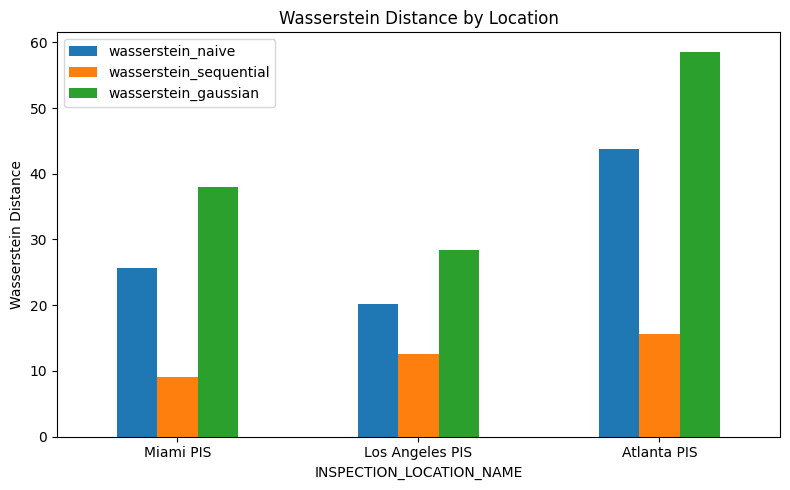

In [46]:
import matplotlib.pyplot as plt

wasserstein_df.plot(
    x='INSPECTION_LOCATION_NAME',
    y=['wasserstein_naive', 'wasserstein_sequential','wasserstein_gaussian'],
    kind='bar',
    figsize=(8, 5)
)
plt.ylabel('Wasserstein Distance')
plt.title('Wasserstein Distance by Location')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

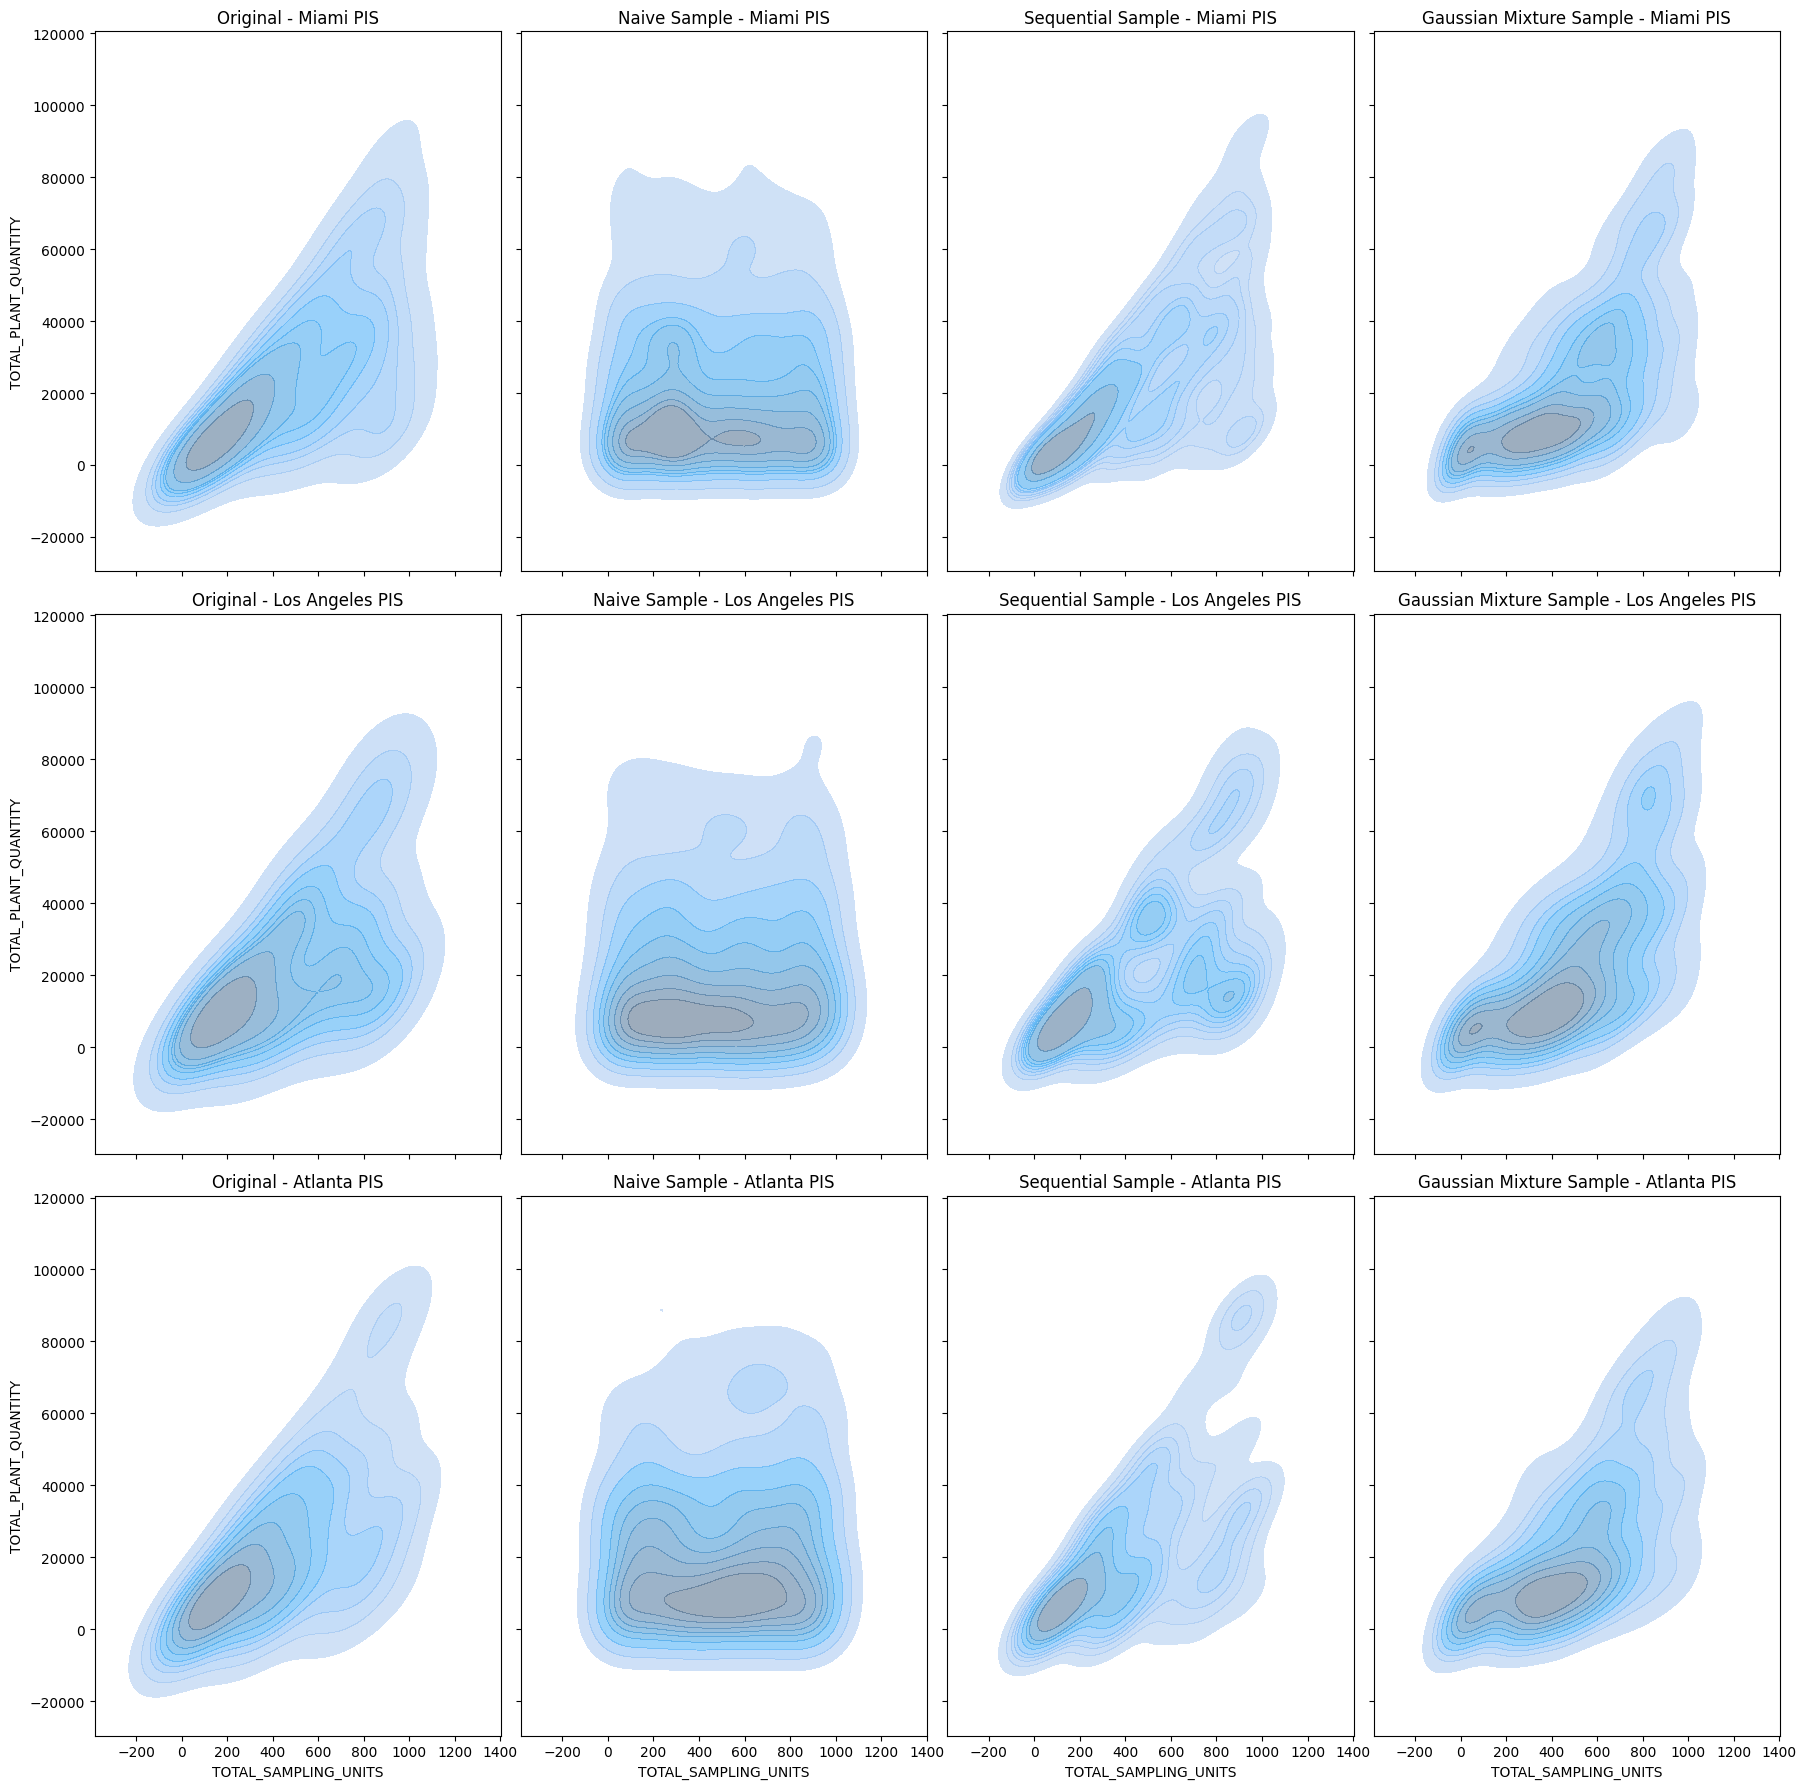

In [48]:
import seaborn as sns
import matplotlib.pyplot as plt

# Prepare a list of unique PIS stations
pis_stations = df['INSPECTION_LOCATION_NAME'].unique()
datasets = [
    (df, "Original"),
    (sampled_df, "Naive Sample"),
    (sequential_sampled_df, "Sequential Sample"),
    (gmm_sampled_df, "Gaussian Mixture Sample")
]

fig, axes = plt.subplots(len(pis_stations), len(datasets), figsize=(18, 6 * len(pis_stations)), sharex=True, sharey=True)

for i, pis in enumerate(pis_stations):
    for j, (data, title) in enumerate(datasets):
        ax = axes[i, j] if len(pis_stations) > 1 else axes[j]
        subset = data[data['INSPECTION_LOCATION_NAME'] == pis]
        if not subset.empty:
            sns.kdeplot(
                data=subset,
                x="TOTAL_SAMPLING_UNITS",
                y="TOTAL_PLANT_QUANTITY",
                fill=True,
                ax=ax,
                thresh=0.05,
                alpha=0.5
            )
        ax.set_title(f"{title} - {pis}")
        ax.set_xlabel("TOTAL_SAMPLING_UNITS")
        ax.set_ylabel("TOTAL_PLANT_QUANTITY")

plt.tight_layout()
plt.show()

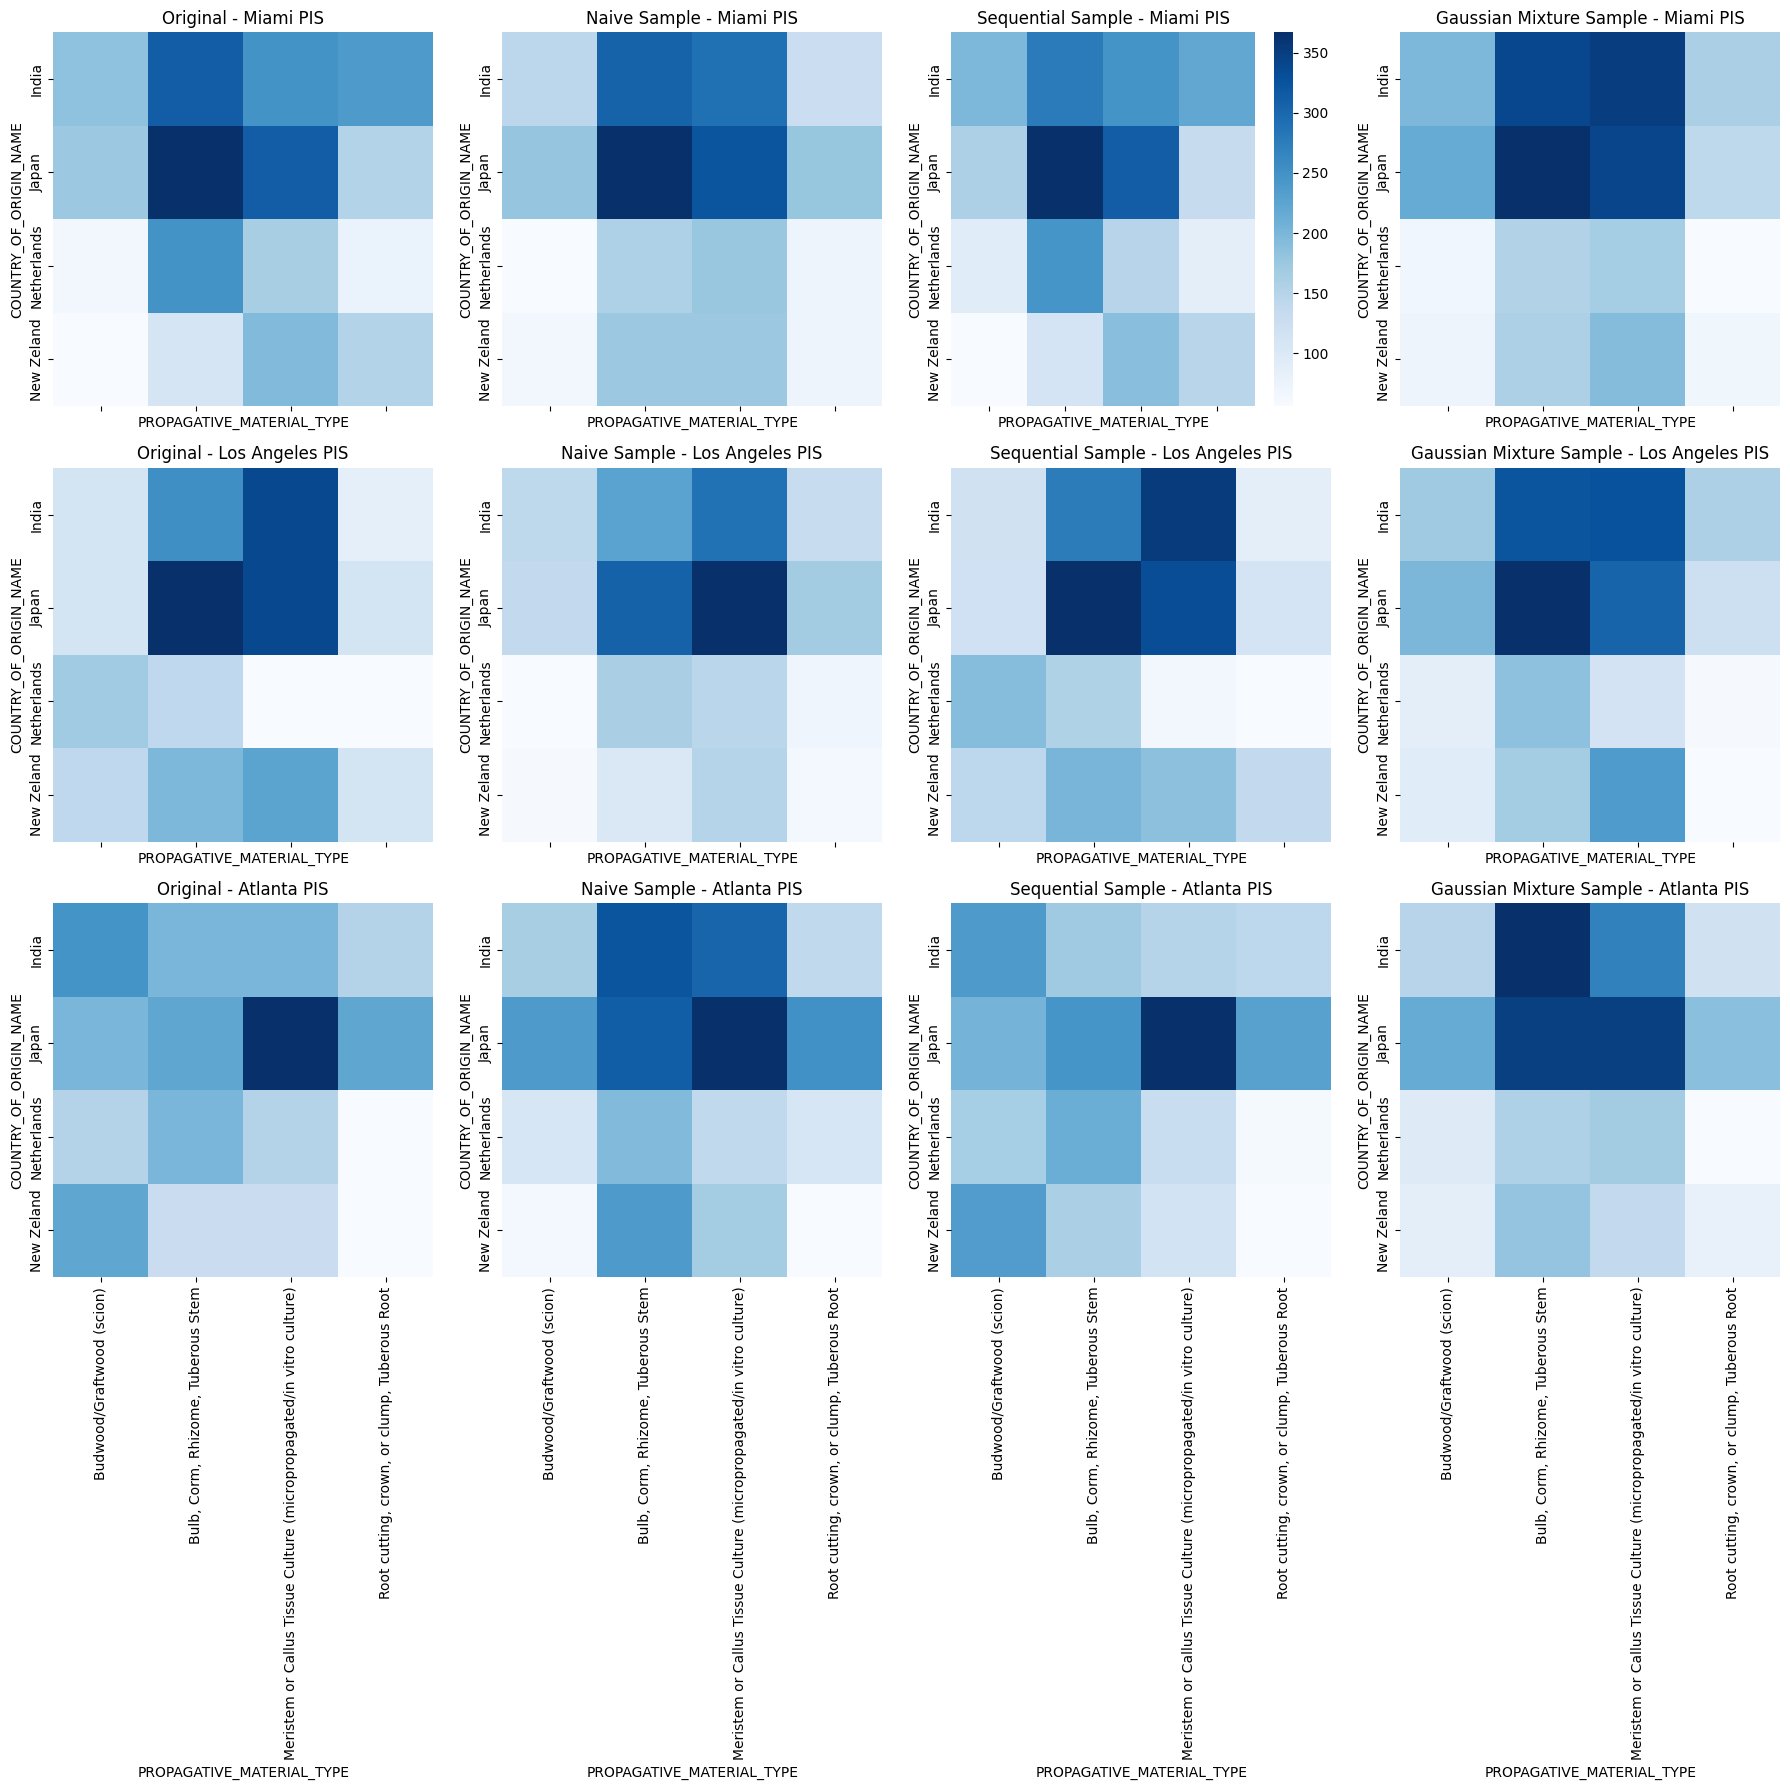

In [49]:
import seaborn as sns
import matplotlib.pyplot as plt

pis_stations = df['INSPECTION_LOCATION_NAME'].unique()
datasets = [
    (df, "Original"),
    (sampled_df, "Naive Sample"),
    (sequential_sampled_df, "Sequential Sample"),
    (gmm_sampled_df, "Gaussian Mixture Sample")
]

fig, axes = plt.subplots(len(pis_stations), len(datasets), figsize=(18, 6 * len(pis_stations)), sharex=True)

for i, pis in enumerate(pis_stations):
    for j, (data, title) in enumerate(datasets):
        ax = axes[i, j] if len(pis_stations) > 1 else axes[j]
        subset = data[data['INSPECTION_LOCATION_NAME'] == pis]
        if not subset.empty:
            # Create a pivot table of counts
            pivot = subset.pivot_table(
                index="COUNTRY_OF_ORIGIN_NAME",
                columns="PROPAGATIVE_MATERIAL_TYPE",
                aggfunc="size",
                fill_value=0
            )
            sns.heatmap(
                pivot,
                cmap="Blues",
                ax=ax,
                cbar=(i == 0 and j == 2)  # Only show colorbar on the last plot of the first row
            )
        ax.set_title(f"{title} - {pis}")
        ax.set_xlabel("PROPAGATIVE_MATERIAL_TYPE")
        ax.set_ylabel("COUNTRY_OF_ORIGIN_NAME")

plt.tight_layout()
plt.show()